# Chapter 5. 자동미분과 최적화

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 1**

## 학습 목표
- Parameter-shift rule이 양자 회로의 미분을 어떻게 정확히 계산하는지 확인
- `qml.grad`로 자동 미분 사용하기
- 여러 옵티마이저(GradientDescent, Adam, QNG) 비교
- 학습 곡선을 그리며 수렴 속도 관찰

In [4]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 5.1 Parameter-shift rule 직접 확인
회전 게이트의 미분은 다음 공식으로 정확히 계산된다.

$$\frac{\partial f}{\partial \theta} = \frac{1}{2}\left[ f(\theta+\pi/2) - f(\theta-\pi/2) \right]$$

이 공식을 손으로 구현하고, 해석적 미분값과 비교한다.

In [5]:
dev = qml.device('default.qubit', wires=1)

@qml.qnode(dev)
def f(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# 이 회로는 해석적으로 f(theta) = cos(theta), df/dtheta = -sin(theta)
theta0 = 1.234

# 1. Parameter-shift rule을 직접 적용
shift = np.pi / 2
grad_param_shift = 0.5 * (f(theta0 + shift) - f(theta0 - shift))

# 2. 해석적 미분
grad_analytic = -np.sin(theta0)

# 3. PennyLane의 qml.grad
grad_qml = qml.grad(f)(pnp.array(theta0, requires_grad=True))

print(f'parameter-shift : {grad_param_shift:+.10f}')
print(f'analytic        : {grad_analytic:+.10f}')
print(f'qml.grad        : {grad_qml:+.10f}')

parameter-shift : -0.9438182094
analytic        : -0.9438182094
qml.grad        : -0.9438182094


세 값이 정확히 일치한다 — parameter-shift rule이 해석적으로 정확한 공식임을 확인했다.

## 5.2 다변수 미분 (gradient vector)
여러 파라미터에 대한 gradient를 한 번에 구할 수 있다.

In [6]:
dev3 = qml.device('default.qubit', wires=3)

@qml.qnode(dev3, interface='autograd')
def multi_param_circuit(params):
    for i in range(3):
        qml.RY(params[i], wires=i)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(2))

params = pnp.array([0.5, 1.0, -0.3], requires_grad=True)
grad_fn = qml.grad(multi_param_circuit)
gradient = grad_fn(params)

print(f'f(params) = {multi_param_circuit(params):+.4f}')
print(f'gradient  = {gradient}')

f(params) = +0.5162
gradient  = [ 0.         -0.80388794  0.15967025]


## 5.3 옵티마이저 비교 — 같은 문제, 다른 알고리즘
단순한 cost를 세 가지 옵티마이저로 최소화하며 학습 곡선을 비교한다.

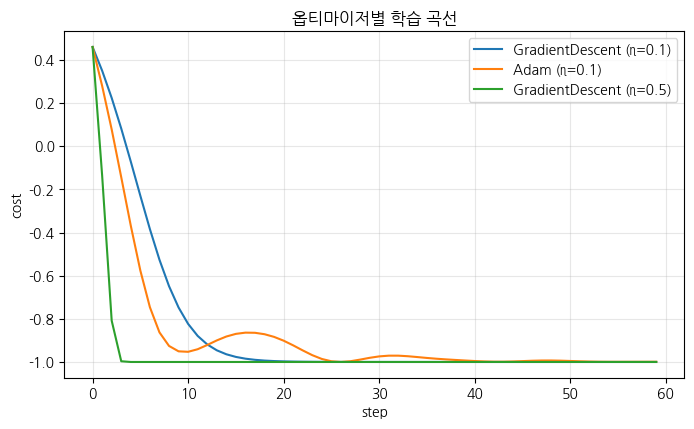

In [7]:
dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev, interface='autograd')
def circuit(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

def cost(params):
    # 목표: <Z_0 Z_1> = -1 (최소값)
    return circuit(params)

optimizers = {
    'GradientDescent (η=0.1)': qml.GradientDescentOptimizer(0.1),
    'Adam (η=0.1)':            qml.AdamOptimizer(0.1),
    'GradientDescent (η=0.5)': qml.GradientDescentOptimizer(0.5),
}

histories = {}
init = np.array([0.4, 0.5, 0.6, 0.7])
for name, opt in optimizers.items():
    params = pnp.array(init.copy(), requires_grad=True)
    hist = []
    for _ in range(60):
        params, c = opt.step_and_cost(cost, params)
        hist.append(c)
    histories[name] = hist

plt.figure(figsize=(8, 4.5))
for name, hist in histories.items():
    plt.plot(hist, label=name)
plt.xlabel('step')
plt.ylabel('cost')
plt.title('옵티마이저별 학습 곡선')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Adam은 모멘텀과 적응형 학습률 덕분에 큰 학습률에서도 안정적이다. 단순 SGD는 학습률 조정에 민감하다.

## 5.4 미분 방법 선택
`diff_method` 인자로 미분 방식을 직접 지정할 수 있다.

In [8]:
methods = ['parameter-shift', 'backprop', 'finite-diff', 'adjoint']
import time

for method in methods:
    dev_x = qml.device('default.qubit', wires=3)
    @qml.qnode(dev_x, diff_method=method, interface='autograd')
    def circ(params):
        qml.RY(params[0], wires=0)
        qml.RY(params[1], wires=1)
        qml.RY(params[2], wires=2)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 2])
        return qml.expval(qml.PauliZ(0))
    params = pnp.array([0.1, 0.2, 0.3], requires_grad=True)
    grad_fn = qml.grad(circ)
    start = time.perf_counter()
    g = grad_fn(params)
    elapsed = (time.perf_counter() - start) * 1000
    print(f'{method:18s}: grad={np.round(g, 6)} ({elapsed:.2f} ms)')

parameter-shift   : grad=[-0.099833  0.        0.      ] (14.75 ms)
backprop          : grad=[-0.099833  0.        0.      ] (4.09 ms)
finite-diff       : grad=[-0.099833  0.        0.      ] (8.65 ms)
adjoint           : grad=[-0.099833 -0.       -0.      ] (2.81 ms)


**4가지 방법별 특성**
- `parameter-shift`: 양자 하드웨어에서도 동작하는 해석적 정확 미분 — 파라미터 수에 비례해 회로 평가 횟수 증가
- `backprop`: 시뮬레이터 전용, 자동미분 그래프 기반으로 한 번에 모든 gradient 계산 — 가장 빠르지만 메모리 사용 큼
- `finite-diff`: 단순 유한차분 근사 — 학습용으로는 권장 안 됨
- `adjoint`: 시뮬레이터 전용, 상태 벡터를 "역방향"으로 전파하며 모든 gradient를 한 번의 forward + 한 번의 backward로 — backprop보다 메모리 효율적

## 5.5 Adjoint differentiation 깊이 보기
Adjoint 미분은 양자 회로 시뮬레이션에서 가장 효율적인 미분 방법으로, **큰 회로에서 backprop보다 메모리를 훨씬 적게 사용**한다.

**핵심 아이디어:** 회로의 출력 ⟨ψ|O|ψ⟩에서 시작해 마지막 게이트의 켤레(adjoint)를 양쪽 상태 벡터에 적용하면서 "되감기"한다. 각 게이트 위치에서 generator를 끼우면 그 파라미터의 gradient를 얻는다. P개 파라미터에 대해 회로 평가는 **1회 + 부분 평가** 수준이다.

산업용 PennyLane 시뮬레이터인 `lightning.qubit`은 adjoint를 기본 미분 방식으로 사용한다.

n_qubits=3: backprop=14.2ms, adjoint=10.9ms, parameter-shift=67.2ms
n_qubits=5: backprop=10.6ms, adjoint=14.1ms, parameter-shift=122.1ms
n_qubits=7: backprop=27.8ms, adjoint=20.6ms, parameter-shift=220.2ms


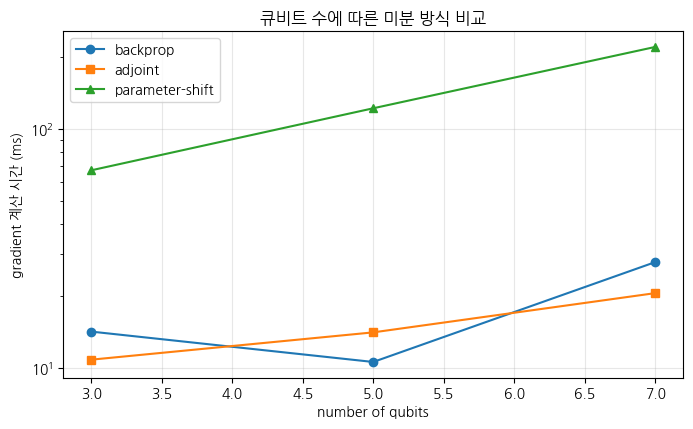

/sessions/modest-friendly-noether/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/modest-friendly-noether/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/modest-friendly-noether/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/modest-friendly-noether/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/modest-friendly-noether/.local/lib/python3.10/site-packages/IPython/core/py

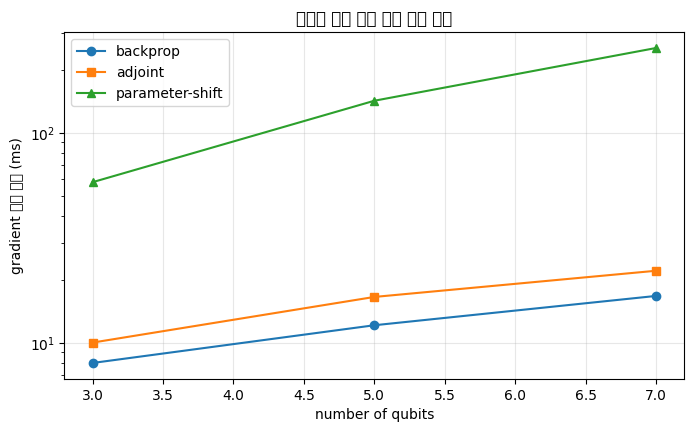

In [9]:
# 큐비트 수가 늘 때 adjoint vs backprop 시간 비교
def make_qnode(method, n_q):
    dev = qml.device('default.qubit', wires=n_q)
    @qml.qnode(dev, diff_method=method, interface='autograd')
    def circ(weights):
        qml.StronglyEntanglingLayers(weights, wires=range(n_q))
        return qml.expval(qml.PauliZ(0))
    return circ

qubit_counts = [3, 5, 7]
n_layers = 3
times_backprop, times_adjoint, times_psr = [], [], []

for n_q in qubit_counts:
    shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_q)
    weights = pnp.array(np.random.RandomState(0).uniform(0, 2 * np.pi, shape),
                         requires_grad=True)
    for method, container in zip(
        ['backprop', 'adjoint', 'parameter-shift'],
        [times_backprop, times_adjoint, times_psr],
    ):
        circ = make_qnode(method, n_q)
        # 2회 평균
        start = time.perf_counter()
        for _ in range(2):
            qml.grad(circ)(weights)
        container.append((time.perf_counter() - start) / 2 * 1000)
    print(f'n_qubits={n_q}: backprop={times_backprop[-1]:.1f}ms, '
          f'adjoint={times_adjoint[-1]:.1f}ms, '
          f'parameter-shift={times_psr[-1]:.1f}ms')

plt.figure(figsize=(8, 4.5))
plt.plot(qubit_counts, times_backprop, 'o-', label='backprop')
plt.plot(qubit_counts, times_adjoint, 's-', label='adjoint')
plt.plot(qubit_counts, times_psr, '^-', label='parameter-shift')
plt.xlabel('number of qubits')
plt.ylabel('gradient 계산 시간 (ms)')
plt.title('큐비트 수에 따른 미분 방식 비교')
plt.legend(); plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

**관찰.** 작은 회로(3-5큐비트)에서는 backprop이 가장 빠르지만, 큐비트가 많아질수록 **adjoint의 메모리 효율성**이 두드러진다. Parameter-shift는 파라미터 수에 비례해 회로 평가가 늘어 가장 느리다.

**선택 가이드:**
- **시뮬레이터 + 작은 회로 (< 10큐비트):** `backprop` 사용
- **시뮬레이터 + 큰 회로 (10큐비트 이상):** `adjoint` 사용 (`lightning.qubit`이 기본)
- **실제 양자 하드웨어:** `parameter-shift`만 사용 가능

## 5.6 학습 풀 예제 — Bell 상태 만들기
임의의 2큐비트 회로로 Bell 상태에 가까운 상태를 만들도록 학습한다.
fidelity = |⟨Φ+|ψ(θ)⟩|² 을 최대화한다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

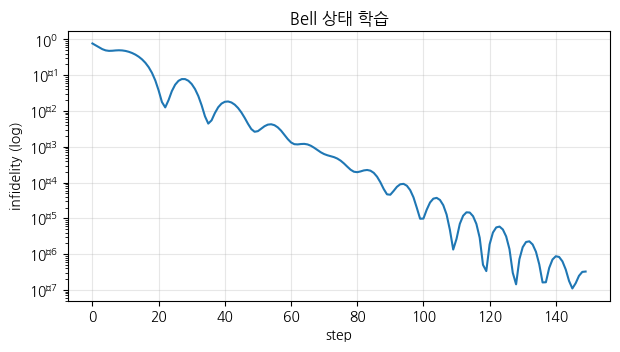

최종 infidelity = 3.26e-07
학습된 상태: [-0.707+0.j -0.001+0.j -0.   +0.j -0.707+0.j]


In [10]:
dev = qml.device('default.qubit', wires=2)
target_state = np.array([1, 0, 0, 1]) / np.sqrt(2)  # |Φ+>

@qml.qnode(dev, interface='autograd')
def state_circuit(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.state()

def infidelity(params):
    psi = state_circuit(params)
    return 1 - pnp.abs(pnp.conj(target_state) @ psi) ** 2

params = pnp.array(np.random.RandomState(0).uniform(0, 2 * np.pi, 4),
                   requires_grad=True)
opt = qml.AdamOptimizer(0.1)
history = []
for step in range(150):
    params, c = opt.step_and_cost(infidelity, params)
    history.append(c)

plt.figure(figsize=(7, 3.5))
plt.semilogy(history)
plt.xlabel('step')
plt.ylabel('infidelity (log)')
plt.title('Bell 상태 학습')
plt.grid(alpha=0.3)
plt.show()
print(f'최종 infidelity = {history[-1]:.2e}')
print('학습된 상태:', np.round(state_circuit(params), 3))

## 5.7 정리
- Parameter-shift rule은 양자 회로 미분의 해석적 공식이며, 하드웨어에서 사용 가능하다.
- `qml.grad`로 다변수 gradient를 한 번에 구한다.
- `qml.AdamOptimizer`가 대부분의 경우 안전한 선택이다.
- 시뮬레이터에서는 `backprop`(작은 회로) 또는 `adjoint`(큰 회로)가 표준이다.
- 4-way 비교: parameter-shift / backprop / adjoint / finite-diff